<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula03_pesquisadosdadosdevendadocomercio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CURSO: Análise de Conjuntura usando Python - Análise Macro<br>
AULA: Coleta e tratamento de dados das Vendas do Comércio<br>
INFORMAÇÔES: saiba mais sobre a Pesquisa Mensal de Comércio (PMC/IBGE) no link https://www.ibge.gov.br/estatisticas/economicas/comercio/9227-pesquisa-mensal-de-comercio.html<br>
AUTOR: Fernando da Silva/Cientista de dados

# Bibliotecas

In [ ]:
# Instalação de bibliotecas
!pip install sidrapy

# Importar bibliotecas
import sidrapy as sidra
import pandas as pd

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Dados

In [ ]:
# Coleta de dados
dados_brutos = sidra.get_table(
    table_code = "8186",
    territorial_level = "1",
    ibge_territorial_code = "all",
    variable = "11706,11707,11708,11709,11710,11711",
    classifications = {"11046": "56736"},
    period = "all"
)
dados_brutos

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,Variável (Código),Variável,Tipos de índice (Código),Tipos de índice
1,1,Brasil,30,Número-índice,44.33677,1,Brasil,200301,janeiro 2003,11706,PMC - Número-índice (2014=100),56736,Índice de volume de vendas no comércio varejis...
2,1,Brasil,30,Número-índice,45.78024,1,Brasil,200301,janeiro 2003,11707,PMC - Número-índice com ajuste sazonal (2014=100),56736,Índice de volume de vendas no comércio varejis...
3,1,Brasil,,,...,1,Brasil,200301,janeiro 2003,11708,"PMC - Variação mês/mês imediatamente anterior,...",56736,Índice de volume de vendas no comércio varejis...
4,1,Brasil,,,...,1,Brasil,200301,janeiro 2003,11709,PMC - Variação mês/mesmo mês do ano anterior (...,56736,Índice de volume de vendas no comércio varejis...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,1,Brasil,30,Número-índice,94.74310,1,Brasil,202207,julho 2022,11707,PMC - Número-índice com ajuste sazonal (2014=100),56736,Índice de volume de vendas no comércio varejis...
1407,1,Brasil,2,%,-0.7,1,Brasil,202207,julho 2022,11708,"PMC - Variação mês/mês imediatamente anterior,...",56736,Índice de volume de vendas no comércio varejis...
1408,1,Brasil,2,%,-6.8,1,Brasil,202207,julho 2022,11709,PMC - Variação mês/mesmo mês do ano anterior (...,56736,Índice de volume de vendas no comércio varejis...
1409,1,Brasil,2,%,-0.8,1,Brasil,202207,julho 2022,11710,PMC - Variação acumulada no ano (em relação ao...,56736,Índice de volume de vendas no comércio varejis...


In [ ]:
# Tratamentos de dados
dados = (
    dados_brutos.rename(columns = dados_brutos.iloc[0])
    .rename(
        columns = {
            "Mês (Código)": "data",
            "Valor": "valor",
            "Variável": "variavel"
            }
        )
    .query("valor not in ['Valor', '...']")
    .filter(items = ["data", "variavel", "valor"], axis = "columns")
    .assign(
        data = lambda x: pd.to_datetime(x.data, format = "%Y%m"),
        valor = lambda x: x.valor.astype(float)
        )
    .replace(
        to_replace = {
            "variavel": {
                "PMC - Número-índice (2014=100)": "Nº índice",
                "PMC - Número-índice com ajuste sazonal (2014=100)": "Nº índice s.a.",
                "PMC - Variação mês/mês imediatamente anterior, com ajuste sazonal (M/M-1)": "Var. % margem",
                "PMC - Variação mês/mesmo mês do ano anterior (M/M-12)": "Var. % interanual",
                "PMC - Variação acumulada no ano (em relação ao mesmo período do ano anterior)": "Var. % acum. ano",
                "PMC - Variação acumulada em 12 meses (em relação ao período anterior de 12 meses)": "Var. % anual"
            }
        }
    )
    .pivot(index = "data", columns = "variavel", values = "valor")
 )
dados

variavel,Nº índice,Nº índice s.a.,Var. % acum. ano,Var. % anual,Var. % interanual,Var. % margem
data,,,,,,
2003-01-01,44.33677,45.78024,NaN,NaN,NaN,NaN
2003-02-01,42.70139,47.09933,NaN,NaN,NaN,2.9
2003-03-01,42.79225,45.79661,NaN,NaN,NaN,-2.8
2003-04-01,43.70079,45.66023,NaN,NaN,NaN,-0.3
2003-05-01,45.60872,45.19642,NaN,NaN,NaN,-1.0
...,...,...,...,...,...,...
2022-03-01,96.56767,98.39070,1.4,4.5,5.3,-0.9
2022-04-01,93.43963,97.41632,1.5,2.2,1.6,-1.0
2022-05-01,98.47646,97.91899,1.0,0.3,-0.7,0.5


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fcb061d33d0>,
      dtype=object)

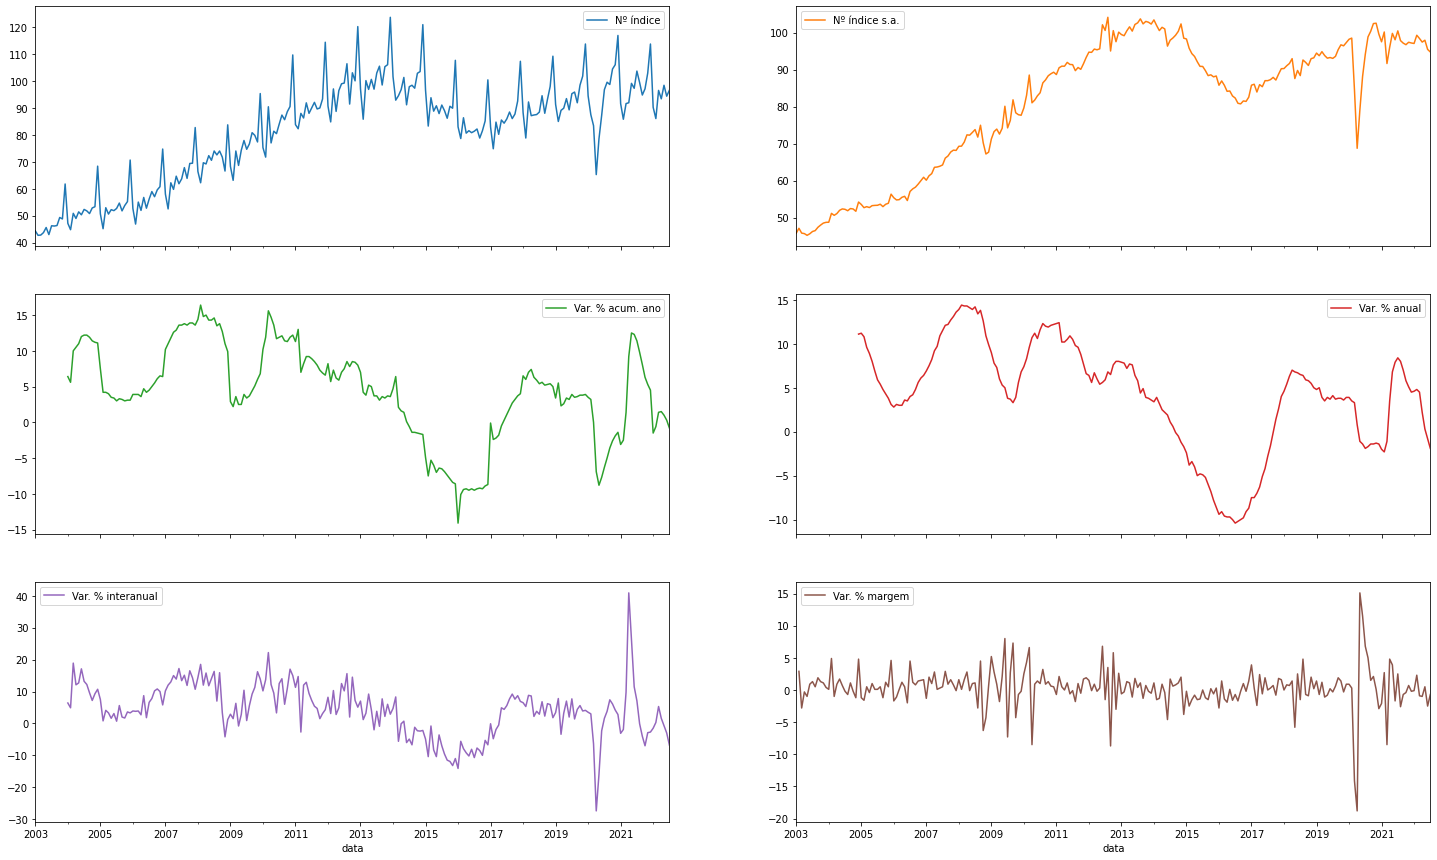

In [ ]:
# Visualização de dados
dados.plot(subplots = True, figsize = (25, 15), layout = (3, 2))